In [1]:
import pandas as pd
import numpy as np

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(r"C:\\Users\\mailm\\Documents\\medilens-ai\\data\\diabetes.csv", header=None, names= columns)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


In [2]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    float64
dtypes: float64(9)
memory usage: 54.2 KB


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (769, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    float64
dtypes: float64(9)
memory usage: 54.2 KB


In [4]:
# For statistics
df.describe

<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            NaN      NaN            NaN            NaN      NaN   NaN   
1            6.0    148.0           72.0           35.0      0.0  33.6   
2            1.0     85.0           66.0           29.0      0.0  26.6   
3            8.0    183.0           64.0            0.0      0.0  23.3   
4            1.0     89.0           66.0           23.0     94.0  28.1   
..           ...      ...            ...            ...      ...   ...   
764         10.0    101.0           76.0           48.0    180.0  32.9   
765          2.0    122.0           70.0           27.0      0.0  36.8   
766          5.0    121.0           72.0           23.0    112.0  26.2   
767          1.0    126.0           60.0            0.0      0.0  30.1   
768          1.0     93.0           70.0           31.0      0.0  30.4   

     DiabetesPedigreeFunction   Age  Outcome  
0                         NaN 

In [5]:
# Marking Nan For missing values of BMI

zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean = df.copy()
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

print("Missing values per column:")
print(df_clean.isnull().sum())

Missing values per column:
Pregnancies                   1
Glucose                       6
BloodPressure                36
SkinThickness               228
Insulin                     375
BMI                          12
DiabetesPedigreeFunction      1
Age                           1
Outcome                       1
dtype: int64


In [6]:
# Filling missing values with medians

for col in zero_as_missing:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

print("Ab missing values:")
print(df_clean.isnull().sum())

Ab missing values:
Pregnancies                 1
Glucose                     1
BloodPressure               1
SkinThickness               1
Insulin                     1
BMI                         1
DiabetesPedigreeFunction    1
Age                         1
Outcome                     1
dtype: int64


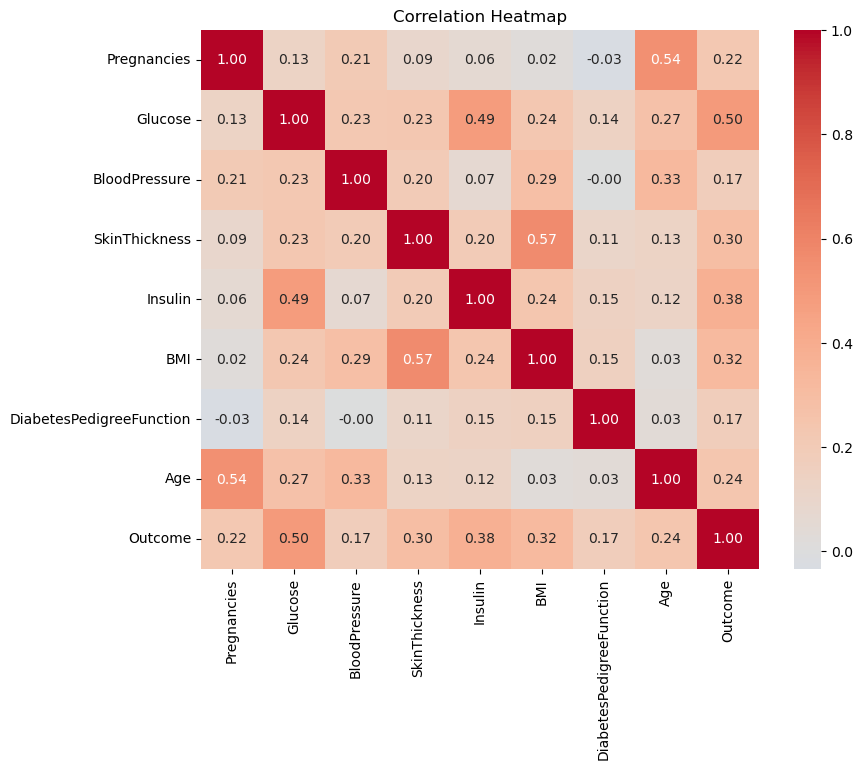


Features most correlated with Outcome (diabetes):
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

print("\nFeatures most correlated with Outcome (diabetes):")
print(corr["Outcome"].drop("Outcome").sort_values(key=abs, ascending=False))

In [10]:
df_clean.to_csv(r"C:\\Users\\mailm\\Documents\\medilens-ai\\data\\diabetes_clean.csv", index=False)
print("Saved! Shape:", df_clean.shape)

Saved! Shape: (769, 9)
